# FP-Cox Optimizer — SaDE v6

Self-Adaptive Differential Evolution for Fractional Polynomial Cox model selection.

**New in v6:**
- `_test_ph_assumption()` — Grambsch-Therneau test via Schoenfeld residuals (for both models)
- `_print_model_equations()` — explicit log-HR equations for both Traditional and FP Cox
- `run_cross_validation()` — k-fold CV using `lifelines.utils.k_fold_cross_validation` with paired t-test
- `_plot_cv_scores()` — per-fold bar chart + boxplot comparison
- `run_sklearn_cv()` — scikit-learn-compatible CV via lifelines' `sklearn_adapter`
- `validate_algorithm()` — multi-seed stability / consensus / convergence analysis

**Design answers (v6 docstring):**
- **FP1 or FP2?** Each covariate is given **two** power slots (`dim = 2 × n_covariates`). When SaDE selects index 0 (= `None`) for the second slot the covariate degrades to **FP1**; otherwise it is **FP2**. The choice is made *adaptively per covariate*.
- **Simultaneous covariates?** All `len(covariates)` are optimised *at the same time* (one integer search space of dimension `2 × n_covariates`).

In [1]:
"""
FP-Cox Optimizer — SaDE v6
==========================
All fixes from v5 are retained.  New additions:

ADD 1  (Methodological)
    _test_ph_assumption() — tests the PH assumption AFTER final model
    selection using scaled Schoenfeld residuals (Grambsch & Therneau 1994).
    Wraps lifelines CoxPHFitter.check_assumptions() which implements the
    same test as R's cox.zph().  Called automatically for both models at
    the end of _fit_final_models().

ADD 2  (Interpretability)
    _print_model_equations() — prints the explicit log-partial-hazard
    equation for both models:
        log[h(t|x)/h₀(t)] = Σ βᵢ·φᵢ(x)
    For the FP model it also annotates the biological interpretation of
    each power (e.g. 'x^0.5 = sqrt', 'x^0 = log').

ADD 3  (Validation)
    run_cross_validation() — k-fold CV using lifelines' native
    k_fold_cross_validation().  Reports mean/std/min/max per model,
    performs a paired t-test, and calls _plot_cv_scores().
    NOTE: powers are fixed post-selection; only Cox coefficients are
    re-estimated per fold (standard post-selection CV practice).

ADD 4  (Validation)
    run_sklearn_cv() — demonstrates scikit-learn-compatible CV using
    lifelines.utils.sklearn_adapter + sklearn cross_val_score.

ADD 5  (Algorithm diagnostics)
    validate_algorithm() — runs n independent SaDE optimisations with
    different seeds and reports: objective stability (CV%), solution
    consensus, and plots convergence curves + objective distribution.
"""

"\nFP-Cox Optimizer — SaDE v6\n==========================\nAll fixes from v5 are retained.  New additions:\n\nADD 1  (Methodological)\n    _test_ph_assumption() — tests the PH assumption AFTER final model\n    selection using scaled Schoenfeld residuals (Grambsch & Therneau 1994).\n    Wraps lifelines CoxPHFitter.check_assumptions() which implements the\n    same test as R's cox.zph().  Called automatically for both models at\n    the end of _fit_final_models().\n\nADD 2  (Interpretability)\n    _print_model_equations() — prints the explicit log-partial-hazard\n    equation for both models:\n        log[h(t|x)/h₀(t)] = Σ βᵢ·φᵢ(x)\n    For the FP model it also annotates the biological interpretation of\n    each power (e.g. 'x^0.5 = sqrt', 'x^0 = log').\n\nADD 3  (Validation)\n    run_cross_validation() — k-fold CV using lifelines' native\n    k_fold_cross_validation().  Reports mean/std/min/max per model,\n    performs a paired t-test, and calls _plot_cv_scores().\n    NOTE: powers are

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional, Union
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

try:
    from sksurv.metrics import integrated_brier_score
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    print('scikit-survival not found — IBS skipped.')

In [3]:
# ---------------------------------------------------------------------------
# Result container
# ---------------------------------------------------------------------------

@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)

In [4]:
# ---------------------------------------------------------------------------
# FIX 7: _choose accepts int OR list for excl
# ---------------------------------------------------------------------------

def _choose(n: int, k: int, excl: Union[int, list], rng) -> np.ndarray:
    mask = np.ones(n, dtype=bool)
    if isinstance(excl, int):
        excl = [excl]
    for e in excl:
        mask[e] = False
    pool = np.where(mask)[0]
    if len(pool) < k:
        return rng.choice(pool, size=k, replace=True)
    return rng.choice(pool, size=k, replace=False)

In [5]:
# ---------------------------------------------------------------------------
# Mutation strategies
# ---------------------------------------------------------------------------

def _s1(pop, F, t, b, rng):                          # DE/rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3])


def _s2(pop, F, t, b, rng):                          # DE/current-to-best/2
    r1, r2, r3, r4 = _choose(len(pop), 4, [t, b], rng)
    return (pop[t]
            + F * (pop[b]  - pop[t])
            + F * (pop[r1] - pop[r2])
            + F * (pop[r3] - pop[r4]))


def _s3(pop, F, t, b, rng):                          # DE/current-to-rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F * (pop[r1] - pop[t]) + F * (pop[r2] - pop[r3])


def _s4(pop, F, t, b, rng):                          # DE/rand/2
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F * (pop[r2] - pop[r3]) + F * (pop[r4] - pop[r5])


_STRATS = [_s1, _s2, _s3, _s4]
_NS     = len(_STRATS)

In [6]:
# ---------------------------------------------------------------------------
# Boundary repair and binomial crossover
# ---------------------------------------------------------------------------

def _repair(v: np.ndarray, lb: np.ndarray, ub: np.ndarray) -> np.ndarray:
    v = np.round(v).astype(int)
    lo = v < lb
    v[lo] = lb[lo] + (lb[lo] - v[lo])
    hi = v > ub
    v[hi] = ub[hi] - (v[hi] - ub[hi])
    return np.clip(v, lb, ub)


def _cross(x: np.ndarray, v: np.ndarray, CR: float, rng) -> np.ndarray:
    d = len(x)
    m = rng.random(d) < CR
    m[rng.integers(d)] = True
    return np.where(m, v, x)

In [7]:
# ---------------------------------------------------------------------------
# SaDE engine
# ---------------------------------------------------------------------------

class _SaDE:
    """
    Self-Adaptive Differential Evolution engine for integer search spaces.

    Strategy pool
    -------------
    _s1  DE/rand/1
    _s2  DE/current-to-best/2
    _s3  DE/current-to-rand/1
    _s4  DE/rand/2

    Adaptation rules (original SaDE — Qin, Huang & Suganthan 2009)
    ---------------------------------------------------------------
    Strategy probabilities updated every lp generations:
        p_k  ∝  0.05 + 0.95 * ns_k / (ns_k + nf_k)
    CRM updated via mean of successful CRs in a sliding window of size lp.

    Scale-factor F
    --------------
    F ~ Cauchy(0.5, 0.3), clipped to (0, 2].  JADE-style extension.
    """

    def __init__(self, func, bounds, pop_size=50, max_evals=1000,
                 lp=10, patience=10, seed=None, callback=None):
        self.func     = func
        self.bounds   = bounds
        self.dim      = len(bounds)
        self.lb       = np.array([b[0] for b in bounds], dtype=int)
        self.ub       = np.array([b[1] for b in bounds], dtype=int)
        self.N        = pop_size
        self.maxev    = max_evals
        self.lp       = lp
        self.patience = patience
        self.cb       = callback
        self.rng      = np.random.default_rng(seed)
        self.p        = np.ones(_NS) / _NS
        self.crm      = np.full(_NS, 0.5)
        self.ns       = [deque() for _ in range(_NS)]
        self.nf       = [deque() for _ in range(_NS)]
        self.crok     = [deque() for _ in range(_NS)]
        # ADD 5: track strategy selection counts for validation
        self.strategy_counts  = np.zeros(_NS, dtype=int)
        self.strategy_success = np.zeros(_NS, dtype=int)

    def run_opt(self, init_pop: Optional[np.ndarray] = None) -> _SaDEResult:
        if (init_pop is not None
                and init_pop.shape == (self.N, self.dim)):
            pop = np.clip(np.round(init_pop).astype(int), self.lb, self.ub)
        else:
            pop = self.rng.integers(self.lb, self.ub + 1,
                                    size=(self.N, self.dim))

        fit        = np.array([self.func(pop[i]) for i in range(self.N)])
        nfev       = self.N
        bi         = int(np.argmin(fit))
        hist       = [float(fit[bi])]
        gen        = 0
        no_improve = 0
        best_ever  = float(fit[bi])

        while nfev < self.maxev:
            gen += 1
            for i in range(self.N):
                if nfev >= self.maxev:
                    break
                k  = self.rng.choice(_NS, p=self.p)
                F  = float(np.clip(
                        self.rng.standard_cauchy() * 0.3 + 0.5, 1e-6, 2.0))
                CR = float(np.clip(
                        self.rng.normal(self.crm[k], 0.1), 0.0, 1.0))
                v  = _STRATS[k](pop, F, i, bi, self.rng).astype(float)
                u  = _repair(
                        _cross(pop[i].astype(float), v, CR, self.rng),
                        self.lb, self.ub)
                fu = self.func(u)
                nfev += 1
                self.strategy_counts[k] += 1
                if fu <= fit[i]:
                    pop[i], fit[i] = u, fu
                    self.ns[k].append(1)
                    self.crok[k].append(CR)
                    self.strategy_success[k] += 1
                    if fu < fit[bi]:
                        bi = i
                else:
                    self.nf[k].append(1)

            if gen % self.lp == 0:
                self._upd_p()
                self._upd_crm()

            hist.append(float(fit[bi]))
            if self.cb:
                self.cb(pop[bi], fit[bi], gen)

            if self.patience > 0:
                if fit[bi] < best_ever - 1e-8:
                    best_ever  = float(fit[bi])
                    no_improve = 0
                else:
                    no_improve += 1
                if no_improve >= self.patience:
                    print(f'  Early stop at gen {gen} '
                          f'(no improvement for {self.patience} gens, '
                          f'evals used: {nfev})')
                    break

        return _SaDEResult(x=pop[bi].copy(), fun=float(fit[bi]),
                           nfev=nfev, ngen=gen, history=hist)

    def _upd_p(self):
        ns  = np.array([sum(q) for q in self.ns], dtype=float)
        nf  = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(ns + nf > 0, ns / (ns + nf), 0.0)
        tot = r.sum()
        if tot > 0:
            self.p = 0.05 + 0.95 * r / tot
            self.p /= self.p.sum()
        for k in range(_NS):
            while len(self.ns[k]) > self.lp:
                self.ns[k].popleft()
            while len(self.nf[k]) > self.lp:
                self.nf[k].popleft()

    def _upd_crm(self):
        for k in range(_NS):
            if self.crok[k]:
                self.crm[k] = float(np.mean(list(self.crok[k])))
            while len(self.crok[k]) > self.lp:
                self.crok[k].popleft()


print('SaDE v6 engine loaded.')

SaDE v6 engine loaded.


In [8]:
# ---------------------------------------------------------------------------
# FPCoxOptimizer v6
# ---------------------------------------------------------------------------

class FPCoxOptimizer:
    """
    FP-Cox Optimizer v6.

    Searches for the optimal fractional polynomial power combination for
    each covariate using Self-Adaptive Differential Evolution (SaDE), then
    fits a Cox proportional hazards model on the transformed covariates.

    FP1 vs FP2
    ----------
    Each covariate has TWO power slots in the search space.  When the second
    slot is index 0 (= None) the covariate reduces to FP1; otherwise it is
    FP2.  The algorithm selects FP1 or FP2 adaptively per covariate.

    Simultaneous optimisation
    -------------------------
    All len(covariates) covariates are optimised simultaneously.  The search
    space dimension is 2 * len(covariates) integers.

    Parameters
    ----------
    df           : pandas DataFrame  (training data)
    covariates   : list of continuous covariate column names to FP-transform
    duration_col : name of the survival time column
    event_col    : name of the event indicator column (1=event, 0=censored)
    penalizer    : ridge penalizer passed to lifelines CoxPHFitter (default 0.01)
    gamma        : c-index weight in the objective:
                   objective = BIC_unpenalized − gamma × n_events × C-index
                   Set gamma=0 for pure BIC minimisation.
    strata_cols  : covariates to stratify on (for PH-violating variables)
    df_test      : optional held-out test DataFrame for unbiased IBS
    """

    POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
                 0,    0.25, 0.5, 1,  1.5,  2,  2.5,  3]
    N_POWERS  = len(POWER_SET)   # 16

    def __init__(self, df, covariates, duration_col, event_col,
                 penalizer=0.01, gamma=0.0, strata_cols=None, df_test=None):

        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.penalizer    = penalizer
        self.gamma        = gamma
        self.strata_cols  = strata_cols or []

        self.df, self._scales = self._preprocess_positive(df, covariates)

        if df_test is not None:
            self.df_test, _ = self._preprocess_positive(
                df_test, covariates, scales=self._scales)
        else:
            self.df_test = None

        self._n_events = int(self.df[self.event_col].sum())

        self._precomp = {}
        self._log_x   = {}
        for col in covariates:
            x     = self.df[col].values.astype(float)
            log_x = np.log(x)
            self._log_x[col] = log_x
            for p in [p for p in self.POWER_SET if p is not None]:
                z = log_x if p == 0 else np.power(x, p)
                if np.isfinite(z).all():
                    self._precomp[(col, p)] = z

        const_cols = {
            self.duration_col: self.df[self.duration_col].values,
            self.event_col:    self.df[self.event_col].values,
        }
        for c in self.strata_cols:
            const_cols[c] = self.df[c].values
        self._const_df = pd.DataFrame(const_cols, index=self.df.index)

        self.evaluation_cache  = {}
        self.best_val          = np.inf
        self.history: list     = []
        self.best_powers: list = []
        self.final_fp_model    = None
        self.traditional_model = None
        self.metrics_: dict    = {}
        self._df_trad_final    = None
        self._df_fp_final      = None
        self.cv_results_: dict = {}

    # -----------------------------------------------------------------------
    # Preprocessing
    # -----------------------------------------------------------------------

    @staticmethod
    def _preprocess_positive(df, features, scales=None):
        df = df.copy()
        computed_scales = {}
        for col in features:
            x = df[col].astype(float)
            if (x <= 0).any():
                x = x - x.min() + 1e-5
            if scales is not None:
                scale = scales[col]
            else:
                mean_abs = np.mean(np.abs(x))
                scale = 1.0 if mean_abs == 0 else 10.0 ** np.floor(np.log10(mean_abs))
            computed_scales[col] = scale
            df[col] = x / scale
        return df, computed_scales

    # -----------------------------------------------------------------------
    # Cache key
    # -----------------------------------------------------------------------

    @staticmethod
    def _canonical_key(indices):
        key = list(indices)
        for i in range(0, len(key), 2):
            a, b = key[i], key[i + 1]
            if b == 0 and a != 0:
                key[i], key[i + 1] = 0, a
            elif a != 0 and b != 0:
                key[i], key[i + 1] = min(a, b), max(a, b)
        return tuple(key)

    # -----------------------------------------------------------------------
    # FP feature builder
    # -----------------------------------------------------------------------

    def _generate_fp_features(self, features, powers):
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active:
                continue
            if len(active) == 1:
                p   = active[0]
                arr = self._precomp.get((col, p))
                if arr is None:
                    return None
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active
                za = self._precomp.get((col, pa))
                if za is None:
                    return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:
                    transformed[f'{col}_fp2_rep_{pb}'] = za * self._log_x[col]
                else:
                    zb = self._precomp.get((col, pb))
                    if zb is None:
                        return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed

    # -----------------------------------------------------------------------
    # Objective function
    # -----------------------------------------------------------------------

    def _objective_function(self, x):
        key = self._canonical_key(x)
        if key in self.evaluation_cache:
            return self.evaluation_cache[key]

        powers = [
            (self.POWER_SET[key[2 * i]], self.POWER_SET[key[2 * i + 1]])
            for i in range(len(self.covariates))
        ]

        fp_cols = self._generate_fp_features(self.covariates, powers)
        if not fp_cols:
            self.evaluation_cache[key] = 1e10
            return 1e10

        df_model = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            df_model[col_name] = arr

        strata = self.strata_cols or None

        try:
            cph_unpen = CoxPHFitter(penalizer=0.0)
            cph_unpen.fit(df_model,
                          duration_col  = self.duration_col,
                          event_col     = self.event_col,
                          strata        = strata,
                          show_progress = False)
            k   = len(cph_unpen.params_)
            bic = (-2 * cph_unpen.log_likelihood_
                   + k * np.log(self._n_events))
            if self.gamma > 0:
                cph_pen = CoxPHFitter(penalizer=self.penalizer)
                cph_pen.fit(df_model,
                            duration_col  = self.duration_col,
                            event_col     = self.event_col,
                            strata        = strata,
                            show_progress = False)
                ci = cph_pen.concordance_index_
            else:
                ci = 0.0
            val = bic - self.gamma * self._n_events * ci
        except Exception:
            val = 1e10

        self.evaluation_cache[key] = val
        if val < self.best_val:
            self.best_val = val
        return val

    # -----------------------------------------------------------------------
    # Warm-start
    # -----------------------------------------------------------------------

    def _warm_start_pop(self, pop_size, rng):
        dim  = 2 * len(self.covariates)
        pop  = rng.integers(0, self.N_POWERS, size=(pop_size, dim))
        NA, LIN, SQRT, LG, Q = 0, 11, 10, 8, 13
        seeds = [
            np.tile([LIN,  NA],   len(self.covariates)),
            np.tile([SQRT, NA],   len(self.covariates)),
            np.tile([LG,   NA],   len(self.covariates)),
            np.tile([LIN,  SQRT], len(self.covariates)),
            np.tile([LIN,  Q],    len(self.covariates)),
        ]
        for row, s in enumerate(seeds[:min(len(seeds), pop_size)]):
            pop[row] = s
        return pop

    def _callback(self, best_x, best_f, gen):
        self.history.append(self.best_val)

    # -----------------------------------------------------------------------
    # IBS
    # -----------------------------------------------------------------------

    def _compute_ibs(self, cph, df_for_model,
                     df_test_model=None, y_test=None):
        if not HAS_SKSURV:
            return None
        try:
            y_train = Surv.from_arrays(
                event = self.df[self.event_col].astype(bool).values,
                time  = self.df[self.duration_col].values)
            t_min  = self.df[self.duration_col].min()
            t_max  = self.df[self.duration_col].max()
            times  = np.linspace(t_min, t_max * 0.999, 100)
            if df_test_model is not None and y_test is not None:
                surv = cph.predict_survival_function(df_test_model, times=times)
                return float(integrated_brier_score(y_train, y_test, surv.T.values, times))
            else:
                print('  WARNING: IBS computed on training data '
                      '(optimistic). Supply df_test for unbiased estimate.')
                surv = cph.predict_survival_function(df_for_model, times=times)
                return float(integrated_brier_score(y_train, y_train, surv.T.values, times))
        except Exception:
            return None

    # -----------------------------------------------------------------------
    # Main entry point
    # -----------------------------------------------------------------------

    def optimize(self, maxiter=15, popsize=8, seed=42, max_evals=None):
        """
        Run SaDE optimisation to select FP powers, then fit final models.

        Parameters
        ----------
        maxiter   : maximum generations
        popsize   : population multiplier per dimension
        seed      : RNG seed
        max_evals : total evaluation budget
        """
        dim      = 2 * len(self.covariates)
        pop_size = popsize * dim

        if max_evals is None:
            max_evals = pop_size * maxiter

        lp       = max(3, maxiter // 5)
        patience = max(3, maxiter // 3)

        print(f'Starting SaDE v6  (gamma={self.gamma})')
        print(f'  FP covariates : {self.covariates}')
        print(f'  Simultaneous  : {len(self.covariates)} covariates '
              f'| dim={dim}  (FP2 max per covariate; FP1 if p2=None)')
        if self.strata_cols:
            print(f'  Strata        : {self.strata_cols}')
        print(f'  Scales applied: '
              + ', '.join(f'{c}÷{s:.3g}' for c, s in self._scales.items()))
        print(f'  n={len(self.df)}, n_events={self._n_events}  '
              f'(BIC uses n_events)')
        print(f'  Pop size      : {pop_size}  |  '
              f'Max gens : {maxiter}  |  '
              f'Budget : {max_evals} evals')
        print(f'  lp (adapt)    : every {lp} gens  |  '
              f'patience (stop) : {patience} gens')
        print(f'  Objective     : ' +
              (f'BIC(unpen) − {self.gamma}·n_events·c-index'
               if self.gamma > 0 else 'BIC(unpenalized) only'))

        rng      = np.random.default_rng(seed)
        init_pop = self._warm_start_pop(pop_size, rng)

        engine = _SaDE(
            func      = self._objective_function,
            bounds    = [(0, self.N_POWERS - 1)] * dim,
            pop_size  = pop_size,
            max_evals = max_evals,
            lp        = lp,
            patience  = patience,
            seed      = seed,
            callback  = self._callback,
        )
        result = engine.run_opt(init_pop=init_pop)

        best_indices = result.x
        print('\n--- Optimal Power Selection ---')
        for i in range(len(self.covariates)):
            p1 = self.POWER_SET[best_indices[2 * i]]
            p2 = self.POWER_SET[best_indices[2 * i + 1]]
            self.best_powers.append((p1, p2))
            fp_type = 'FP1' if p2 is None else 'FP2'
            print(f'  {self.covariates[i]:<22}: p1={str(p1):<7} p2={str(p2):<7}  [{fp_type}]')
        if self.strata_cols:
            print(f'  Stratified on : {self.strata_cols}')
        print(f'\n  Best objective : {result.fun:.4f}')
        print(f'  Generations    : {result.ngen}')
        print(f'  Evaluations    : {result.nfev}  '
              f'(cache hits: {result.nfev - len(self.evaluation_cache)})')

        # Strategy success rates
        total_use = engine.strategy_counts.sum()
        if total_use > 0:
            print(f'\n--- Strategy Usage & Success Rates ---')
            names = ['DE/rand/1', 'DE/current-to-best/2',
                     'DE/current-to-rand/1', 'DE/rand/2']
            for i, name in enumerate(names):
                use = engine.strategy_counts[i]
                suc = engine.strategy_success[i]
                rate = 100 * suc / use if use > 0 else 0.0
                print(f'  {name:<28}: used={use:4d}  success={suc:4d}  '
                      f'rate={rate:5.1f}%')

        self._plot_convergence()
        self._fit_final_models()

    def _plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(self.history) + 1), self.history,
                 marker='o', markersize=3, linestyle='-', color='steelblue')
        title = 'SaDE v6 Convergence'
        if self.strata_cols:
            title += f'  (strata: {self.strata_cols})'
        plt.title(title)
        plt.xlabel('Generation')
        plt.ylabel('BIC(unpen) − γ·n_events·c-index'
                   if self.gamma > 0 else 'BIC (unpenalized)')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------------------
    # Final model fitting and comparison
    # -----------------------------------------------------------------------

    def _fit_final_models(self):
        print('\n' + '=' * 68)
        print('FINAL MODEL COMPARISON')
        print('=' * 68)

        strata = self.strata_cols or None

        # --- Traditional Cox ---
        seen, trad_cols = set(), []
        for c in (self.covariates + self.strata_cols +
                  [self.duration_col, self.event_col]):
            if c not in seen:
                trad_cols.append(c)
                seen.add(c)

        self._df_trad_final = self.df[trad_cols].copy()

        self.traditional_model = CoxPHFitter(penalizer=self.penalizer)
        self.traditional_model.fit(
            self._df_trad_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        _trad_unpen = CoxPHFitter(penalizer=0.0)
        _trad_unpen.fit(
            self._df_trad_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        # --- FP Cox ---
        fp_cols = self._generate_fp_features(self.covariates, self.best_powers)
        if fp_cols is None:
            fp_cols = {}
        self._df_fp_final = self._const_df.copy()
        for col_name, arr in fp_cols.items():
            self._df_fp_final[col_name] = arr

        self.final_fp_model = CoxPHFitter(penalizer=self.penalizer)
        self.final_fp_model.fit(
            self._df_fp_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        _fp_unpen = CoxPHFitter(penalizer=0.0)
        _fp_unpen.fit(
            self._df_fp_final,
            duration_col  = self.duration_col,
            event_col     = self.event_col,
            strata        = strata,
            show_progress = False)

        # --- Metrics ---
        n      = self._n_events
        k_t    = len(_trad_unpen.params_)
        k_fp   = len(_fp_unpen.params_)
        bic_t  = -2 * _trad_unpen.log_likelihood_ + k_t  * np.log(n)
        bic_fp = -2 * _fp_unpen.log_likelihood_   + k_fp * np.log(n)

        ci_t   = self.traditional_model.concordance_index_
        ci_fp  = self.final_fp_model.concordance_index_

        if self.df_test is not None:
            df_test_trad = self.df_test[trad_cols].copy()
            test_fp_cols = self._generate_fp_features_on(
                self.df_test, self.covariates, self.best_powers)
            df_test_fp_model = pd.DataFrame(
                {self.duration_col: self.df_test[self.duration_col].values,
                 self.event_col:    self.df_test[self.event_col].values},
                index=self.df_test.index)
            if test_fp_cols:
                for c, a in test_fp_cols.items():
                    df_test_fp_model[c] = a
            for sc in self.strata_cols:
                df_test_fp_model[sc] = self.df_test[sc].values
            y_test = Surv.from_arrays(
                event = self.df_test[self.event_col].astype(bool).values,
                time  = self.df_test[self.duration_col].values
            ) if HAS_SKSURV else None
            ibs_t  = self._compute_ibs(
                self.traditional_model, self._df_trad_final, df_test_trad, y_test)
            ibs_fp = self._compute_ibs(
                self.final_fp_model, self._df_fp_final, df_test_fp_model, y_test)
        else:
            ibs_t  = self._compute_ibs(self.traditional_model, self._df_trad_final)
            ibs_fp = self._compute_ibs(self.final_fp_model, self._df_fp_final)

        self.metrics_ = {
            'C-index (trad)' : round(ci_t,   4),
            'C-index (FP)'   : round(ci_fp,  4),
            'BIC (trad)'     : round(bic_t,  2),
            'BIC (FP)'       : round(bic_fp, 2),
            'IBS (trad)' : round(ibs_t, 4) if ibs_t  is not None else 'N/A',
            'IBS (FP)'   : round(ibs_fp,4) if ibs_fp is not None else 'N/A',
            'k (trad)'       : k_t,
            'k (FP)'         : k_fp,
        }

        W = 22
        hdr = (f"\n{'Metric':<25} | {'Traditional Cox':>{W}} "
               f"| {'FP Cox (SaDE v6)':>{W}}")
        print(hdr)
        print('-' * len(hdr))
        print(f"{'Concordance index':<25} | {ci_t:>{W}.4f} | {ci_fp:>{W}.4f}")
        print(f"{'BIC (unpen, n_events)':<25} | {bic_t:>{W}.2f} | {bic_fp:>{W}.2f}")
        if ibs_t is not None and ibs_fp is not None:
            label = 'IBS (test)' if self.df_test is not None else 'IBS (train, optimistic)'
            print(f"{label:<25} | {ibs_t:>{W}.4f} | {ibs_fp:>{W}.4f}")
        print(f"{'Log-lik (unpen)':<25} | "
              f"{_trad_unpen.log_likelihood_:>{W}.4f} | "
              f"{_fp_unpen.log_likelihood_:>{W}.4f}")
        print(f"{'Parameters (k)':<25} | {k_t:>{W}d} | {k_fp:>{W}d}")
        if strata:
            print(f'  * Both models stratified on: {strata}')
        print(f'\n  Covariate scales (divide raw values by these before scoring new data):')
        for col, sc in self._scales.items():
            print(f'    {col}: ÷{sc:.4g}')

        # ADD 2: model equations
        self._print_model_equations()

        # ADD 1: PH assumption test via Schoenfeld residuals
        self._test_ph_assumption(
            self.traditional_model, self._df_trad_final, 'Traditional Cox')
        self._test_ph_assumption(
            self.final_fp_model, self._df_fp_final, 'FP Cox (SaDE v6)')

    # -----------------------------------------------------------------------
    # ADD 1: PH assumption test — Schoenfeld residuals
    # -----------------------------------------------------------------------

    def _test_ph_assumption(self, model, df_model, model_name='Model',
                            p_threshold=0.05):
        """
        Test the proportional hazards assumption after model selection.

        Method: Grambsch & Therneau (1994)
        -----------------------------------
        1. Compute scaled Schoenfeld residuals for each covariate at each
           event time.
        2. Test whether residuals are correlated with (ranked) event times.
        3. H₀: log-hazard ratio is constant over time (PH holds).
        4. Significant p = time-varying effect = PH possibly violated.

        Uses lifelines CoxPHFitter.check_assumptions(), which is equivalent
        to R's cox.zph() with transform='rank'.

        If PH is violated for a covariate, options include:
          • Add it to strata_cols (stratify out its baseline hazard)
          • Interact it with log(time)
          • Use a time-varying coefficient model
        """
        bar = '=' * 62
        print(f'\n{bar}')
        print(f'  PH ASSUMPTION TEST  —  {model_name}')
        print(bar)
        print('  Method : Grambsch-Therneau (scaled Schoenfeld residuals)')
        print(f'  H₀     : log-HR constant over time  (PH holds)')
        print(f'  H₁     : log-HR varies with time    (PH violated)')
        print(f'  α      : {p_threshold}')

        # --- Part A: lifelines formal test ---
        print('\n  [A] Formal test (lifelines check_assumptions):'
              ' p-values per covariate')
        try:
            results = model.check_assumptions(
                df_model,
                p_value_threshold = p_threshold,
                show_plots        = True,
                warn              = False,
            )
        except Exception as e:
            print(f'  [!] check_assumptions failed: {e}')
            results = None

        # --- Part B: manual Pearson correlation of raw Schoenfeld residuals ---
        print('\n  [B] Pearson correlation: Schoenfeld residuals vs ranked event time')
        print(f'  {"Covariate":<38} {"ρ":>8}  {"|ρ|>0.2?"}')
        print(f'  {"-"*62}')
        any_flagged = False
        try:
            schoenfeld = model.compute_residuals(df_model, kind='schoenfeld')

            # Ranked event times
            event_mask  = df_model[self.event_col].astype(bool).values
            event_times = df_model[self.duration_col].values[event_mask]
            ranked_t    = pd.Series(event_times).rank().values

            for col in schoenfeld.columns:
                res = schoenfeld[col].values
                if len(res) != len(ranked_t):
                    print(f'  {col:<38}  [shape mismatch — skipped]')
                    continue
                rho, pval = scipy_stats.pearsonr(res, ranked_t)
                flag = ' ⚠  |ρ|>0.2 — possible violation' if abs(rho) > 0.2 else ''
                if flag:
                    any_flagged = True
                print(f'  {col:<38} {rho:>8.4f} {flag}')

            print()
            if any_flagged:
                print('  ⚠  Recommendation: consider stratifying flagged covariates')
                print('     or using time-varying coefficients.')
            else:
                print('  ✓  No strong evidence of PH violation from correlation.')

        except Exception as e:
            print(f'  [!] Schoenfeld residuals failed: {e}')
            print('  (Stratified models may require non-strata covariates only.)')

        print(bar)
        return results

    # -----------------------------------------------------------------------
    # ADD 2: Model equation printer
    # -----------------------------------------------------------------------

    def _print_model_equations(self):
        """
        Print the explicit log-partial-hazard equations:

            log[ h(t|x) / h₀(t) ] = β₁·φ₁(x) + β₂·φ₂(x) + ···

        where φᵢ are raw covariates (traditional) or FP terms (FP model).
        Both the linear (log-HR) and exponential (HR) forms are shown.
        """
        bar = '=' * 68
        print(f'\n{bar}')
        print('MODEL EQUATIONS')
        print(bar)
        print('Cox partial log-hazard:  log[ h(t|x) / h₀(t) ] = Σᵢ βᵢ · φᵢ(x)')
        print('Equivalent HR form    :  h(t|x) / h₀(t) = exp( Σᵢ βᵢ · φᵢ(x) )\n')

        def _fmt_power(p):
            """Human-readable description of a single FP power."""
            if p is None:  return 'None (omit)'
            if p == 0:     return 'x^0 = ln(x)'
            if p == 0.5:   return 'x^0.5 = √x'
            if p == 1:     return 'x^1 (linear)'
            if p == 2:     return 'x^2 (quadratic)'
            return f'x^{p}'

        for model, tag, label in [
            (self.traditional_model, 'TRADITIONAL COX', '(untransformed covariates)'),
            (self.final_fp_model,    'FP COX (SaDE v6)', '(fractional polynomial terms)'),
        ]:
            if model is None:
                continue
            params = model.params_
            print(f'== {tag}  {label} ==')
            print(f'  log[ h(t|x) / h₀(t) ] =')
            for feat, coef in params.items():
                sign = '+' if coef >= 0 else '−'
                print(f'    {sign} {abs(coef):.6f} × {feat}')
            print(f'\n  HR form:  exp( {" ".join(f"{c:+.6f}·{f}" for f, c in params.items())} )')
            print(f'\n  k={len(params)},  C-index={model.concordance_index_:.4f},  '
                  f'penalizer={model.penalizer}\n')

        # FP-specific power annotations
        if self.best_powers:
            print('== FP POWER ANNOTATION ==')
            for cov, (p1, p2) in zip(self.covariates, self.best_powers):
                active = [p for p in (p1, p2) if p is not None]
                fp_type = f'FP{len(active)}'
                scale   = self._scales.get(cov, 1.0)
                print(f'  {cov}  [{fp_type}]  (raw ÷ {scale:.4g} before transform)')
                for idx, p in enumerate(active, 1):
                    print(f'    term {idx}: {_fmt_power(p)}')
                if len(active) == 2 and active[0] == active[1]:
                    print(f'    repeated power = term 2 = x^{active[0]} · ln(x)')
            print()

    # -----------------------------------------------------------------------
    # ADD 3: Cross-validation — lifelines native
    # -----------------------------------------------------------------------

    def run_cross_validation(self, k=5,
                             scoring_method='concordance_index',
                             seed=None):
        """
        k-fold cross-validation using lifelines.utils.k_fold_cross_validation.

        Evaluates both the traditional and FP Cox models on the SAME k folds
        and compares them with a paired t-test.

        IMPORTANT — post-selection CV
        -----------------------------
        The FP powers are FIXED at the values found by SaDE on the full
        training set.  Per fold, only the Cox regression coefficients are
        re-estimated (not the powers themselves).  This is standard practice
        in the FP literature and is equivalent to 'post-selection CV'.
        For a fully honest estimate, powers would need to be re-selected in
        each fold — computationally much more expensive.

        Parameters
        ----------
        k              : number of folds (default 5)
        scoring_method : 'concordance_index' or 'log_likelihood'
        seed           : np.random seed for fold splitting

        Returns
        -------
        dict with keys 'cv_trad', 'cv_fp', 'k', 'scoring', 't_stat', 'p_value'
        """
        if self._df_trad_final is None or self._df_fp_final is None:
            raise RuntimeError('Call optimize() before run_cross_validation().')

        bar = '=' * 68
        print(f'\n{bar}')
        print(f'CROSS-VALIDATION  ({k}-fold, metric = {scoring_method})')
        print(bar)
        print(f'  Note: FP powers are FIXED post-selection; '
              f'Cox coefficients re-estimated per fold.')

        if seed is not None:
            np.random.seed(seed)

        strata    = self.strata_cols or None
        fitter_kw = {'strata': strata} if strata else {}

        # --- Traditional ---
        print('\n  Running traditional Cox CV...')
        scores_trad = k_fold_cross_validation(
            CoxPHFitter(penalizer=self.penalizer),
            self._df_trad_final,
            duration_col   = self.duration_col,
            event_col      = self.event_col,
            k              = k,
            scoring_method = scoring_method,
            fitter_kwargs  = fitter_kw,
        )

        # --- FP Cox ---
        print('  Running FP Cox CV...')
        scores_fp = k_fold_cross_validation(
            CoxPHFitter(penalizer=self.penalizer),
            self._df_fp_final,
            duration_col   = self.duration_col,
            event_col      = self.event_col,
            k              = k,
            scoring_method = scoring_method,
            fitter_kwargs  = fitter_kw,
        )

        scores_trad = np.array(scores_trad)
        scores_fp   = np.array(scores_fp)

        # --- Summary table ---
        W = 10
        print(f'\n  {"": <30}  {"Mean":>{W}}  {"Std":>{W}}  {"Min":>{W}}  {"Max":>{W}}')
        print(f'  {"-"*64}')
        print(f'  {"Traditional Cox":<30}  {scores_trad.mean():>{W}.4f}  '
              f'{scores_trad.std():>{W}.4f}  {scores_trad.min():>{W}.4f}  '
              f'{scores_trad.max():>{W}.4f}')
        print(f'  {"FP Cox (SaDE v6)":<30}  {scores_fp.mean():>{W}.4f}  '
              f'{scores_fp.std():>{W}.4f}  {scores_fp.min():>{W}.4f}  '
              f'{scores_fp.max():>{W}.4f}')
        print(f'  {"-"*64}')

        # --- Per-fold detail ---
        print(f'\n  Per-fold scores:')
        print(f'  {"Fold":<6} {"Traditional":>14} {"FP Cox":>14} {"Δ (FP−Trad)":>14}')
        print(f'  {"-"*50}')
        for fold_i, (st, sf) in enumerate(zip(scores_trad, scores_fp), 1):
            delta = sf - st
            marker = ' ↑' if delta > 0 else ' ↓'
            print(f'  {fold_i:<6} {st:>14.4f} {sf:>14.4f} {delta:>14.4f}{marker}')

        # --- Paired t-test ---
        t_stat, p_val = scipy_stats.ttest_rel(scores_fp, scores_trad)
        print(f'\n  Paired t-test  (H₀: mean FP = mean Traditional):')
        print(f'    t = {t_stat:.4f},  p = {p_val:.4f}')
        if p_val < 0.05:
            better = 'FP Cox' if scores_fp.mean() > scores_trad.mean() else 'Traditional Cox'
            print(f'    = {better} is significantly better (p < 0.05)')
        else:
            print(f'    = No statistically significant difference (p ≥ 0.05)')

        # --- Plot ---
        self._plot_cv_scores(scores_trad, scores_fp, k, scoring_method)

        self.cv_results_ = {
            'cv_trad': scores_trad,
            'cv_fp'  : scores_fp,
            'k'      : k,
            'scoring': scoring_method,
            't_stat' : t_stat,
            'p_value': p_val,
        }
        return self.cv_results_

    def _plot_cv_scores(self, scores_trad, scores_fp, k, scoring_method):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        folds = np.arange(1, k + 1)
        metric_label = scoring_method.replace('_', ' ').title()

        # --- Bar chart per fold ---
        ax = axes[0]
        b1 = ax.bar(folds - 0.2, scores_trad, 0.38,
                    label='Traditional Cox', color='steelblue', alpha=0.85)
        b2 = ax.bar(folds + 0.2, scores_fp,   0.38,
                    label='FP Cox (SaDE v6)', color='tomato',    alpha=0.85)
        ax.axhline(scores_trad.mean(), color='steelblue', linestyle='--',
                   lw=1.5, alpha=0.8, label=f'Trad mean={scores_trad.mean():.3f}')
        ax.axhline(scores_fp.mean(), color='tomato',    linestyle='--',
                   lw=1.5, alpha=0.8, label=f'FP mean={scores_fp.mean():.3f}')
        ax.set_xlabel('Fold')
        ax.set_ylabel(metric_label)
        ax.set_title(f'{k}-Fold CV: Score Per Fold')
        ax.set_xticks(folds)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

        # --- Box plot ---
        ax2 = axes[1]
        bp = ax2.boxplot(
            [scores_trad, scores_fp],
            labels=['Traditional\nCox', 'FP Cox\n(SaDE v6)'],
            patch_artist=True,
            widths=0.5,
        )
        colors = ['steelblue', 'tomato']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        for median in bp['medians']:
            median.set_color('black')
            median.set_linewidth(2)
        ax2.set_ylabel(metric_label)
        ax2.set_title('CV Score Distribution')
        ax2.grid(True, alpha=0.3, axis='y')

        plt.suptitle(f'{k}-Fold Cross-Validation Comparison  '
                     f'(metric: {metric_label})',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------------------------
    # ADD 4: Cross-validation via scikit-learn wrapper
    # -----------------------------------------------------------------------

    def run_sklearn_cv(self, k=5, seed=None):
        """
        Demonstrate scikit-learn-compatible cross-validation using
        lifelines.utils.sklearn_adapter.

        The sklearn adapter wraps CoxPHFitter so it satisfies the sklearn
        estimator interface (fit / predict / score), enabling use of
        sklearn.model_selection.cross_val_score, GridSearchCV, etc.

        Requires:
            pip install scikit-learn
            lifelines >= 0.27
        """
        if self._df_trad_final is None or self._df_fp_final is None:
            raise RuntimeError('Call optimize() before run_sklearn_cv().')

        bar = '=' * 68
        print(f'\n{bar}')
        print(f'SKLEARN-COMPATIBLE CROSS-VALIDATION  ({k}-fold)')
        print(bar)

        try:
            from lifelines.utils.sklearn_adapter import sklearn_adapter
            from sklearn.model_selection import cross_val_score, StratifiedKFold
        except ImportError as e:
            print(f'  [!] Import failed: {e}')
            print('  Install: pip install scikit-learn; '
                  'lifelines >= 0.27 required for sklearn_adapter.')
            return None

        try:
            # Create sklearn-compatible Cox estimator tied to the event column
            SKCoxPH = sklearn_adapter(CoxPHFitter,
                                      event_col=self.event_col)

            # Extract feature matrix X and structured survival outcome y
            # for both model variants.
            drop_cols = [self.duration_col, self.event_col] + self.strata_cols

            # Traditional
            X_trad = self._df_trad_final.drop(
                columns=[c for c in drop_cols if c in self._df_trad_final.columns])
            y_trad = self._df_trad_final[self.event_col].values.astype(bool)

            # FP
            X_fp   = self._df_fp_final.drop(
                columns=[c for c in drop_cols if c in self._df_fp_final.columns])
            y_fp   = self._df_fp_final[self.event_col].values.astype(bool)

            cv = StratifiedKFold(n_splits=k, shuffle=True,
                                 random_state=seed)

            clf_trad = SKCoxPH(penalizer=self.penalizer)
            clf_fp   = SKCoxPH(penalizer=self.penalizer)

            # Note: sklearn_adapter's score() returns concordance index
            scores_trad_sk = cross_val_score(
                clf_trad, X_trad, y_trad, cv=cv, scoring='f1_macro')
            scores_fp_sk   = cross_val_score(
                clf_fp,   X_fp,   y_fp,   cv=cv, scoring='f1_macro')

            print(f'  Traditional Cox  (sklearn): '
                  f'{scores_trad_sk.mean():.4f} ± {scores_trad_sk.std():.4f}')
            print(f'  FP Cox (SaDE v6) (sklearn): '
                  f'{scores_fp_sk.mean():.4f} ± {scores_fp_sk.std():.4f}')
            return {'sklearn_trad': scores_trad_sk, 'sklearn_fp': scores_fp_sk}

        except Exception as e:
            print(f'  [!] sklearn CV error: {e}')
            print('  Falling back to lifelines k_fold_cross_validation.')
            # Fall back to the lifelines-native version
            return self.run_cross_validation(k=k, seed=seed)

    # -----------------------------------------------------------------------
    # ADD 5: Algorithm validation
    # -----------------------------------------------------------------------

    def validate_algorithm(self, n_runs=5, seeds=None,
                           maxiter=10, popsize=6):
        """
        Validate the SaDE optimization algorithm.

        Runs n_runs independent optimisations with different RNG seeds and
        measures:

        1. Stability — coefficient of variation (CV%) of best objective
        2. Consensus — fraction of runs that converge to identical powers
        3. Convergence — overlaid convergence curves
        4. Distribution — bar chart of best objectives

        Parameters
        ----------
        n_runs  : number of independent runs (default 5)
        seeds   : list of RNG seeds (default [0, 1, ..., n_runs-1])
        maxiter : generations per run (lighter than the full optimize call)
        popsize : population multiplier per dimension

        Returns
        -------
        dict with 'objectives', 'power_selections', 'consensus'
        """
        if seeds is None:
            seeds = list(range(n_runs))

        bar = '=' * 68
        print(f'\n{bar}')
        print(f'ALGORITHM VALIDATION — {n_runs} independent SaDE runs')
        print(bar)
        print(f'  maxiter={maxiter}, popsize={popsize}, '
              f'dim={2*len(self.covariates)}')
        print(f'  Seeds: {seeds[:n_runs]}\n')

        objectives           = []
        power_selections     = []
        convergence_hists    = []
        strategy_success_all = []

        dim      = 2 * len(self.covariates)
        pop_size = popsize * dim
        max_evals = pop_size * maxiter
        lp       = max(3, maxiter // 5)
        patience = max(3, maxiter // 3)

        for run_i, seed in enumerate(seeds[:n_runs]):
            # Fresh optimizer wrapper (reuses the same df + precomp cache)
            opt_tmp = FPCoxOptimizer(
                df           = self.df.copy(),
                covariates   = list(self.covariates),
                duration_col = self.duration_col,
                event_col    = self.event_col,
                penalizer    = self.penalizer,
                gamma        = self.gamma,
                strata_cols  = list(self.strata_cols),
            )

            rng      = np.random.default_rng(seed)
            init_pop = opt_tmp._warm_start_pop(pop_size, rng)

            engine = _SaDE(
                func      = opt_tmp._objective_function,
                bounds    = [(0, opt_tmp.N_POWERS - 1)] * dim,
                pop_size  = pop_size,
                max_evals = max_evals,
                lp        = lp,
                patience  = patience,
                seed      = seed,
                callback  = opt_tmp._callback,
            )
            result = engine.run_opt(init_pop=init_pop)

            # Decode powers
            pows = []
            for j in range(len(self.covariates)):
                p1 = self.POWER_SET[result.x[2 * j]]
                p2 = self.POWER_SET[result.x[2 * j + 1]]
                pows.append((p1, p2))

            fp_types = ['FP1' if p[1] is None else 'FP2' for p in pows]
            print(f'  Run {run_i+1:2d} (seed={seed}): '
                  f'obj={result.fun:.4f}  '
                  f'gens={result.ngen}  '
                  f'powers={[(str(p[0]),str(p[1])) for p in pows]}  '
                  f'types={fp_types}')

            objectives.append(result.fun)
            power_selections.append(pows)
            convergence_hists.append(result.history)

            total_use = engine.strategy_counts.sum()
            success_rates = [
                engine.strategy_success[i] / engine.strategy_counts[i]
                if engine.strategy_counts[i] > 0 else 0.0
                for i in range(_NS)
            ]
            strategy_success_all.append(success_rates)

        objectives = np.array(objectives)

        # --- Stability ---
        cv_pct = 100 * objectives.std() / abs(objectives.mean())
        print(f'\n  Objective statistics across {n_runs} runs:')
        print(f'    Mean   : {objectives.mean():.4f}')
        print(f'    Std    : {objectives.std():.4f}')
        print(f'    Min    : {objectives.min():.4f}')
        print(f'    Max    : {objectives.max():.4f}')
        print(f'    CV (%) : {cv_pct:.2f}%')
        if cv_pct < 1.0:
            print(f'    ✓  CV < 1% — excellent stability')
        elif cv_pct < 5.0:
            print(f'    ✓  CV < 5% — acceptable stability')
        else:
            print(f'    ⚠  CV ≥ 5% — consider increasing popsize/maxiter')

        # --- Consensus ---
        solutions   = [tuple(tuple(p) for p in run) for run in power_selections]
        most_common = max(set(solutions), key=solutions.count)
        consensus   = solutions.count(most_common)
        print(f'\n  Solution consensus: {consensus}/{n_runs} runs found identical powers')
        print(f'  Most common: {most_common}')
        if consensus == n_runs:
            print(f'  ✓  All runs converged to the same solution.')
        elif consensus >= n_runs * 0.6:
            print(f'  ✓  Majority consensus (≥60%) — solution is stable.')
        else:
            print(f'  ⚠  Low consensus — search space may have multiple near-optimal solutions.')

        # --- Strategy success rates (averaged) ---
        mean_sr = np.mean(strategy_success_all, axis=0)
        strat_names = ['DE/rand/1', 'DE/current-to-best/2',
                       'DE/current-to-rand/1', 'DE/rand/2']
        print(f'\n  Mean strategy success rates across runs:')
        for i, (name, sr) in enumerate(zip(strat_names, mean_sr)):
            print(f'    {name:<28}: {100*sr:.1f}%')

        # --- Plots ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))

        # Convergence curves
        ax1 = axes[0]
        colors = plt.cm.tab10(np.linspace(0, 0.9, n_runs))
        for i, (hist, seed) in enumerate(zip(convergence_hists, seeds[:n_runs])):
            ax1.plot(hist, alpha=0.8, color=colors[i],
                     label=f'Run {i+1} (s={seed})')
        ax1.set_xlabel('Generation')
        ax1.set_ylabel('Best BIC')
        ax1.set_title('Convergence Across Runs')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)

        # Objective bar chart
        ax2 = axes[1]
        run_labels = [f'Run {i+1}' for i in range(n_runs)]
        bar_colors = ['steelblue' if o == objectives.min() else 'lightsteelblue'
                      for o in objectives]
        ax2.bar(run_labels, objectives, color=bar_colors, edgecolor='navy', alpha=0.85)
        ax2.axhline(objectives.mean(), color='red', linestyle='--', lw=2,
                    label=f'Mean={objectives.mean():.2f}')
        ax2.fill_between([-0.5, n_runs - 0.5],
                         objectives.mean() - objectives.std(),
                         objectives.mean() + objectives.std(),
                         alpha=0.15, color='red', label='±1 Std')
        ax2.set_ylabel('Best Objective (BIC)')
        ax2.set_title('Objective by Run')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.tick_params(axis='x', rotation=30)

        # Strategy success rates
        ax3 = axes[2]
        x_pos = np.arange(_NS)
        bar_h = ax3.bar(x_pos, mean_sr * 100, color='mediumpurple',
                        edgecolor='indigo', alpha=0.8)
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(['DE/rand/1', 'curr-to-best/2',
                              'curr-to-rand/1', 'DE/rand/2'],
                             fontsize=8, rotation=20, ha='right')
        ax3.set_ylabel('Success Rate (%)')
        ax3.set_title('Mean Strategy Success Rate')
        ax3.grid(True, alpha=0.3, axis='y')
        for bar_i, val in zip(bar_h, mean_sr * 100):
            ax3.text(bar_i.get_x() + bar_i.get_width() / 2,
                     val + 0.5, f'{val:.1f}%', ha='center', fontsize=9)

        plt.suptitle('SaDE Algorithm Validation', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

        return {
            'objectives'      : objectives,
            'power_selections': power_selections,
            'consensus'       : f'{consensus}/{n_runs}',
            'cv_pct'          : cv_pct,
        }

    def _generate_fp_features_on(self, df, features, powers):
        """Compute FP features on an arbitrary DataFrame (e.g. test set)."""
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            x     = df[col].values.astype(float)
            log_x = np.log(x)
            active = sorted([p for p in (p1, p2) if p is not None])
            if not active:
                continue

            def xp(p):
                z = log_x if p == 0 else np.power(x, p)
                return z if np.isfinite(z).all() else None

            if len(active) == 1:
                p   = active[0]
                arr = xp(p)
                if arr is None:
                    return None
                transformed[f'{col}_fp_{p}'] = arr
            else:
                pa, pb = active
                za = xp(pa)
                if za is None:
                    return None
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:
                    transformed[f'{col}_fp2_rep_{pb}'] = za * log_x
                else:
                    zb = xp(pb)
                    if zb is None:
                        return None
                    transformed[f'{col}_fp2_{pb}'] = zb
        return transformed


print('FPCoxOptimizer v6 loaded.')

FPCoxOptimizer v6 loaded.


## FP1 vs FP2 — Design Answer

| Question | Answer |
|---|---|
| FP1 or FP2? | **FP2 is the maximum per covariate.** Each covariate is allocated 2 integer slots `(p1_idx, p2_idx)`. If SaDE selects index 0 (= `None`) for `p2`, the covariate degrades to **FP1**. If both slots are non-zero the covariate uses **FP2**. The algorithm picks adaptively. |
| How many covariates optimized simultaneously? | **All of them at once.** Search space dimension = `2 × len(covariates)`. For GBSG (5 covariates) `dim=10`; for Haberman (2) `dim=4`; for Simulated (1) `dim=2`. |

**Repeated-power FP2 case:** when `p1 == p2`, the second term is defined as `x^p · ln(x)` (standard FP convention, Royston & Sauerbrei 2008).

## Example Dataset Runs

Edit paths and column names as needed.

Each run:
1. Runs SaDE optimisation
2. Prints optimal powers and strategy success rates
3. Fits final traditional and FP Cox models
4. **NEW** Prints explicit model equations (log-HR form)
5. **NEW** Tests PH assumption via Schoenfeld residuals for both models
6. **NEW** Runs 5-fold cross-validation (lifelines native)
7. **NEW** Validates the SaDE algorithm over 5 independent seeds

Starting SaDE v6  (gamma=0.0)
  FP covariates : ['Age']
  Simultaneous  : 1 covariates | dim=2  (FP2 max per covariate; FP1 if p2=None)
  Strata        : ['Treatment', 'Sex']
  Scales applied: Age÷10
  n=200, n_events=141  (BIC uses n_events)
  Pop size      : 16  |  Max gens : 15  |  Budget : 240 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC(unpenalized) only
  Early stop at gen 11 (no improvement for 5 gens, evals used: 192)

--- Optimal Power Selection ---
  Age                   : p1=3       p2=2.5      [FP2]
  Stratified on : ['Treatment', 'Sex']

  Best objective : 812.1448
  Generations    : 11
  Evaluations    : 192  (cache hits: 134)

--- Strategy Usage & Success Rates ---
  DE/rand/1                   : used=  45  success=  29  rate= 64.4%
  DE/current-to-best/2        : used=  42  success=  25  rate= 59.5%
  DE/current-to-rand/1        : used=  40  success=  23  rate= 57.5%
  DE/rand/2                   : used=  49  success=  25  rat

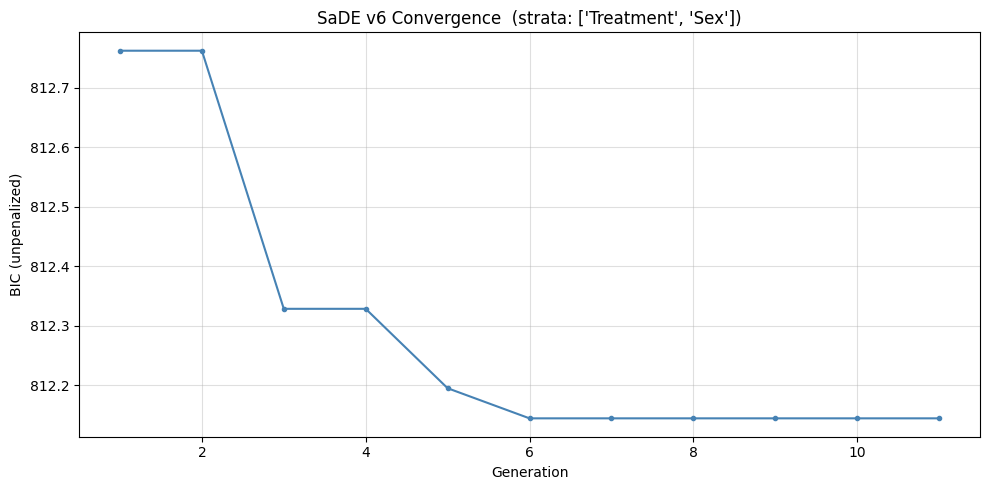


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v6)
----------------------------------------------------------------------------
Concordance index         |                 0.6454 |                 0.6454
BIC (unpen, n_events)     |                 815.62 |                 812.14
IBS (train, optimistic)   |                 0.1233 |                 0.1211
Log-lik (unpen)           |              -405.3373 |              -401.1236
Parameters (k)            |                      1 |                      2
  * Both models stratified on: ['Treatment', 'Sex']

  Covariate scales (divide raw values by these before scoring new data):
    Age: ÷10

MODEL EQUATIONS
Cox partial log-hazard:  log[ h(t|x) / h₀(t) ] = Σᵢ βᵢ · φᵢ(x)
Equivalent HR form    :  h(t|x) / h₀(t) = exp( Σᵢ βᵢ · φᵢ(x) )

== TRADITIONAL COX  (untransformed covariates) ==
  log[ h(t|x) / h₀(t) ] =
    + 0.441120 × Age

  HR form:  exp( +0.441120·Age )

  k=1,  C-index=0.6454,  pe

model,lifelines.CoxPHFitter
duration col,'Time'
event col,'Event'
penalizer,0.01
l1 ratio,0.0
strata,"[Treatment, Sex]"
baseline estimation,breslow
number of observations,200
number of events observed,141
partial log-likelihood,-407.72
time fit was run,2026-03-22 15:20:30 UTC



CROSS-VALIDATION  (5-fold, metric = concordance_index)
  Note: FP powers are FIXED post-selection; Cox coefficients re-estimated per fold.

  Running traditional Cox CV...
  Running FP Cox CV...

                                        Mean         Std         Min         Max
  ----------------------------------------------------------------
  Traditional Cox                     0.6314      0.0646      0.5640      0.7495
  FP Cox (SaDE v6)                    0.6376      0.0637      0.5461      0.7323
  ----------------------------------------------------------------

  Per-fold scores:
  Fold      Traditional         FP Cox    Δ (FP−Trad)
  --------------------------------------------------
  1              0.5640         0.6113         0.0473 ↑
  2              0.6254         0.5461        -0.0793 ↓
  3              0.7495         0.6807        -0.0688 ↓
  4              0.5833         0.7323         0.1490 ↑
  5              0.6349         0.6177        -0.0172 ↓

  Paired t-test  (

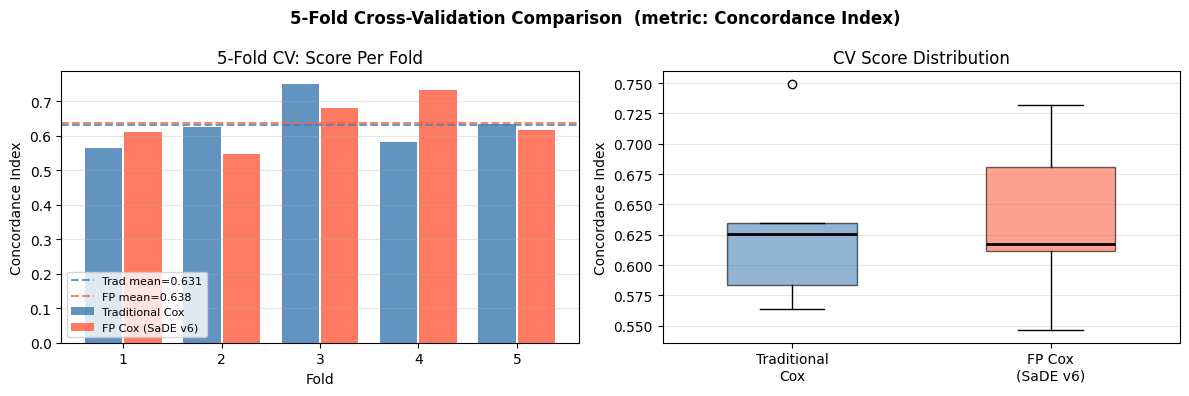


ALGORITHM VALIDATION — 5 independent SaDE runs
  maxiter=10, popsize=6, dim=2
  Seeds: [0, 1, 2, 3, 4]

  Early stop at gen 7 (no improvement for 3 gens, evals used: 96)
  Run  1 (seed=0): obj=811.7339  gens=7  powers=[('-0.5', 'None')]  types=['FP1']
  Early stop at gen 3 (no improvement for 3 gens, evals used: 48)
  Run  2 (seed=1): obj=811.1701  gens=3  powers=[('-3', 'None')]  types=['FP1']
  Early stop at gen 4 (no improvement for 3 gens, evals used: 60)
  Run  3 (seed=2): obj=810.6039  gens=4  powers=[('-1.5', 'None')]  types=['FP1']
  Early stop at gen 4 (no improvement for 3 gens, evals used: 60)
  Run  4 (seed=3): obj=810.5067  gens=4  powers=[('None', '-2')]  types=['FP2']
  Early stop at gen 4 (no improvement for 3 gens, evals used: 60)
  Run  5 (seed=4): obj=810.5067  gens=4  powers=[('-2', 'None')]  types=['FP1']

  Objective statistics across 5 runs:
    Mean   : 810.9043
    Std    : 0.4828
    Min    : 810.5067
    Max    : 811.7339
    CV (%) : 0.06%
    ✓  CV < 1% — 

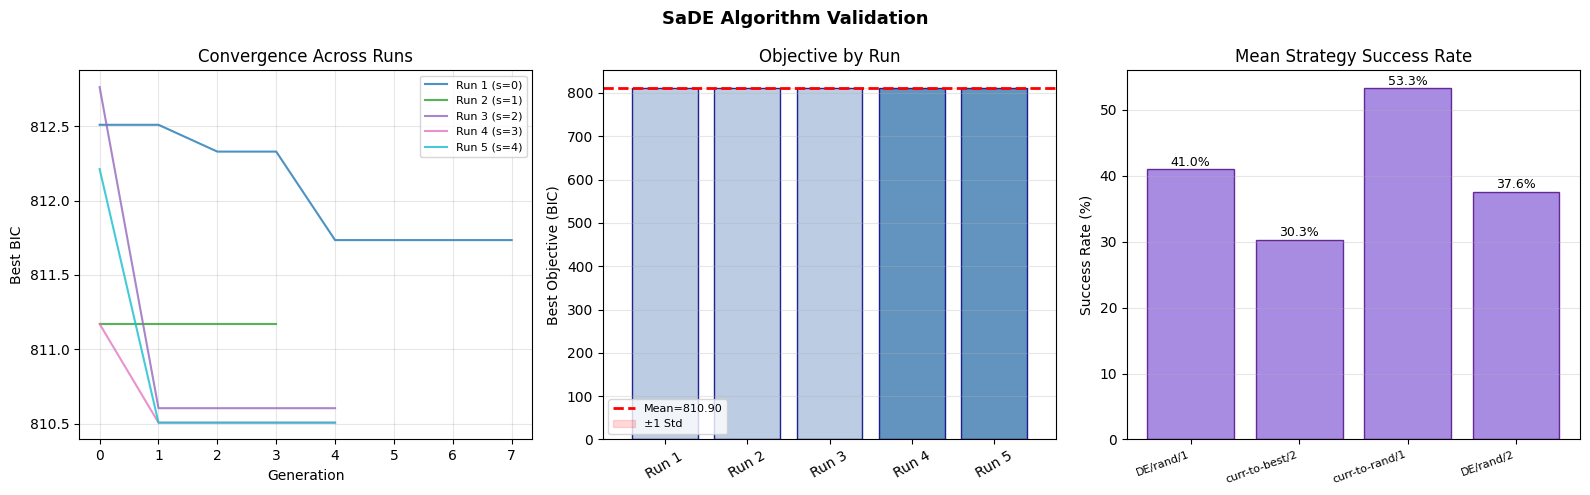

In [9]:
import pandas as pd

# == Dataset 1: Simulated ====================================================
sd_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_simulated_data.csv')
optimizer_sd = FPCoxOptimizer(
    df           = sd_df,
    covariates   = ['Age'],
    duration_col = 'Time',
    event_col    = 'Event',
    strata_cols  = ['Treatment', 'Sex'],
    gamma        = 0.0,
)
optimizer_sd.optimize(maxiter=15, popsize=8, seed=42)
print('\nFP Cox model summary (Simulated):')
optimizer_sd.final_fp_model.print_summary()

# ADD 3: Cross-validation
cv_sd = optimizer_sd.run_cross_validation(k=5, scoring_method='concordance_index', seed=0)

# ADD 5: Algorithm validation
val_sd = optimizer_sd.validate_algorithm(n_runs=5, seeds=[0,1,2,3,4], maxiter=10, popsize=6)

Starting SaDE v6  (gamma=0.0)
  FP covariates : ['PatientAge', 'LogNodes']
  Simultaneous  : 2 covariates | dim=4  (FP2 max per covariate; FP1 if p2=None)
  Scales applied: PatientAge÷10, LogNodes÷0.1
  n=305, n_events=81  (BIC uses n_events)
  Pop size      : 32  |  Max gens : 15  |  Budget : 480 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC(unpenalized) only
  Early stop at gen 5 (no improvement for 5 gens, evals used: 192)

--- Optimal Power Selection ---
  PatientAge            : p1=0.5     p2=None     [FP1]
  LogNodes              : p1=0.5     p2=None     [FP1]

  Best objective : 767.5229
  Generations    : 5
  Evaluations    : 192  (cache hits: 21)

--- Strategy Usage & Success Rates ---
  DE/rand/1                   : used=  39  success=  19  rate= 48.7%
  DE/current-to-best/2        : used=  38  success=  15  rate= 39.5%
  DE/current-to-rand/1        : used=  37  success=  20  rate= 54.1%
  DE/rand/2                   : used=  46  succ

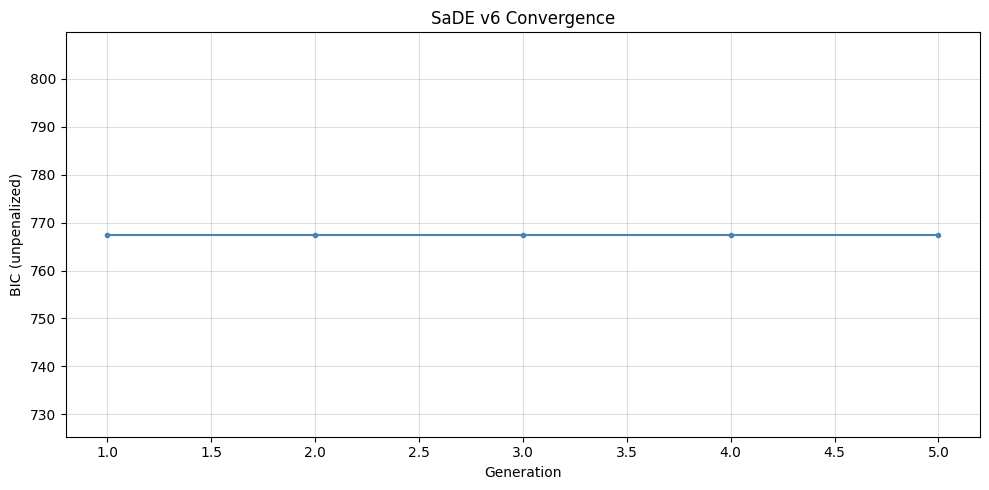


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v6)
----------------------------------------------------------------------------
Concordance index         |                 0.6682 |                 0.6710
BIC (unpen, n_events)     |                 768.78 |                 767.52
IBS (train, optimistic)   |                 0.1598 |                 0.1599
Log-lik (unpen)           |              -379.9943 |              -379.3670
Parameters (k)            |                      2 |                      2

  Covariate scales (divide raw values by these before scoring new data):
    PatientAge: ÷10
    LogNodes: ÷0.1

MODEL EQUATIONS
Cox partial log-hazard:  log[ h(t|x) / h₀(t) ] = Σᵢ βᵢ · φᵢ(x)
Equivalent HR form    :  h(t|x) / h₀(t) = exp( Σᵢ βᵢ · φᵢ(x) )

== TRADITIONAL COX  (untransformed covariates) ==
  log[ h(t|x) / h₀(t) ] =
    + 0.105348 × PatientAge
    + 0.045772 × LogNodes

  HR form:  exp( +0.105348·PatientAge +0.045772·LogNod

<lifelines.CoxPHFitter: fitted with 305 total observations, 224 right-censored observations>
             duration col = 'PatientYearOperation'
                event col = 'SurvivalStatus'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 305
number of events observed = 81
   partial log-likelihood = -379.88
         time fit was run = 2026-03-22 15:21:17 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
PatientAge_fp_0.5  0.53      1.70      0.49           -0.42            1.49                0.65                4.42
LogNodes_fp_0.5    0.26      1.29      0.05            0.15            0.36                1.16                1.44

                   cmp to    z      p  -log2(p)
covariate                                      
PatientAge_fp_0.5    0.00 1.09   0.28      1.86
LogNodes_fp_0.5      0.00 4.78 <0.005     19.15
---
Concordance = 0.67
Partial AIC = 763.75
log-likelihood ratio test = 24.88 on 2 df
-log2(p) of ll-ratio test = 17.95


CROSS-VALIDATION  (5-fold, metric = concordance_index)
  Note: FP powers are FIXED post-selection; Cox coefficients re-estimated per fold.

  Running traditional Cox CV...
  Running FP Cox CV...

                                        Mean         Std         Min         Max
  ----------------------------------------------------------------
  Traditional Cox                     0.6786      0.0457      0.6194      0.7472
  FP Cox (SaDE v6)                    0.6667      0.0554      0.5682      0.7216
  ----------------------------------------------------------------

  Per-fold scores:
  Fold      Traditional         FP Cox    Δ (FP−Trad)
  --------------------------------------------------
  1              0.7472         0.5682        -0.1790 ↓
  2              0.6870         0.7216         0.0346 ↑
  3              0.6380         0.6911         0.0531 ↑
  4              0.7014         0.6460        -0.0554 ↓
  5              0.6194         0.7064         0.0870 ↑

  Paired t-test  (

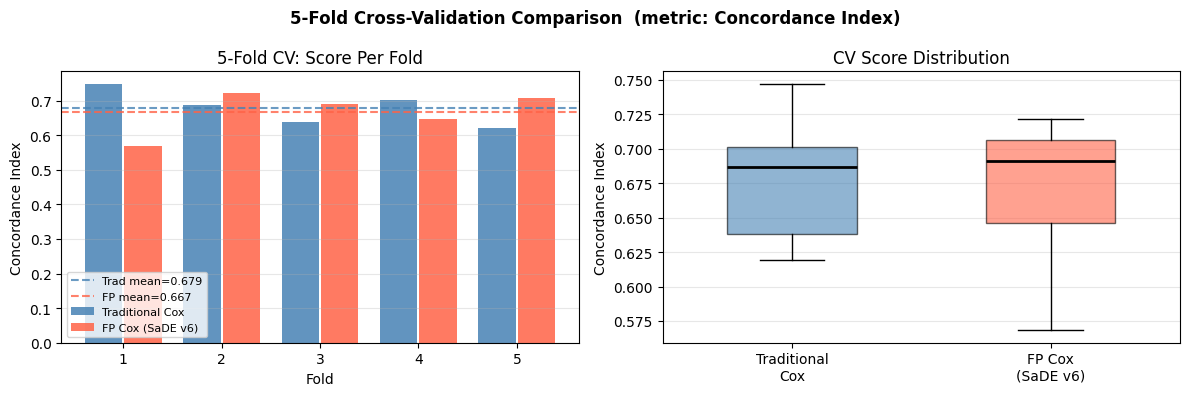


ALGORITHM VALIDATION — 5 independent SaDE runs
  maxiter=10, popsize=6, dim=4
  Seeds: [0, 1, 2, 3, 4]

  Early stop at gen 3 (no improvement for 3 gens, evals used: 96)
  Run  1 (seed=0): obj=767.5229  gens=3  powers=[('0.5', 'None'), ('0.5', 'None')]  types=['FP1', 'FP1']
  Early stop at gen 3 (no improvement for 3 gens, evals used: 96)
  Run  2 (seed=1): obj=767.5229  gens=3  powers=[('0.5', 'None'), ('0.5', 'None')]  types=['FP1', 'FP1']
  Early stop at gen 3 (no improvement for 3 gens, evals used: 96)
  Run  3 (seed=2): obj=767.5229  gens=3  powers=[('0.5', 'None'), ('0.5', 'None')]  types=['FP1', 'FP1']
  Early stop at gen 6 (no improvement for 3 gens, evals used: 168)
  Run  4 (seed=3): obj=767.4155  gens=6  powers=[('0', 'None'), ('0.5', 'None')]  types=['FP1', 'FP1']
  Early stop at gen 3 (no improvement for 3 gens, evals used: 96)
  Run  5 (seed=4): obj=767.5229  gens=3  powers=[('0.5', 'None'), ('0.5', 'None')]  types=['FP1', 'FP1']

  Objective statistics across 5 runs:
  

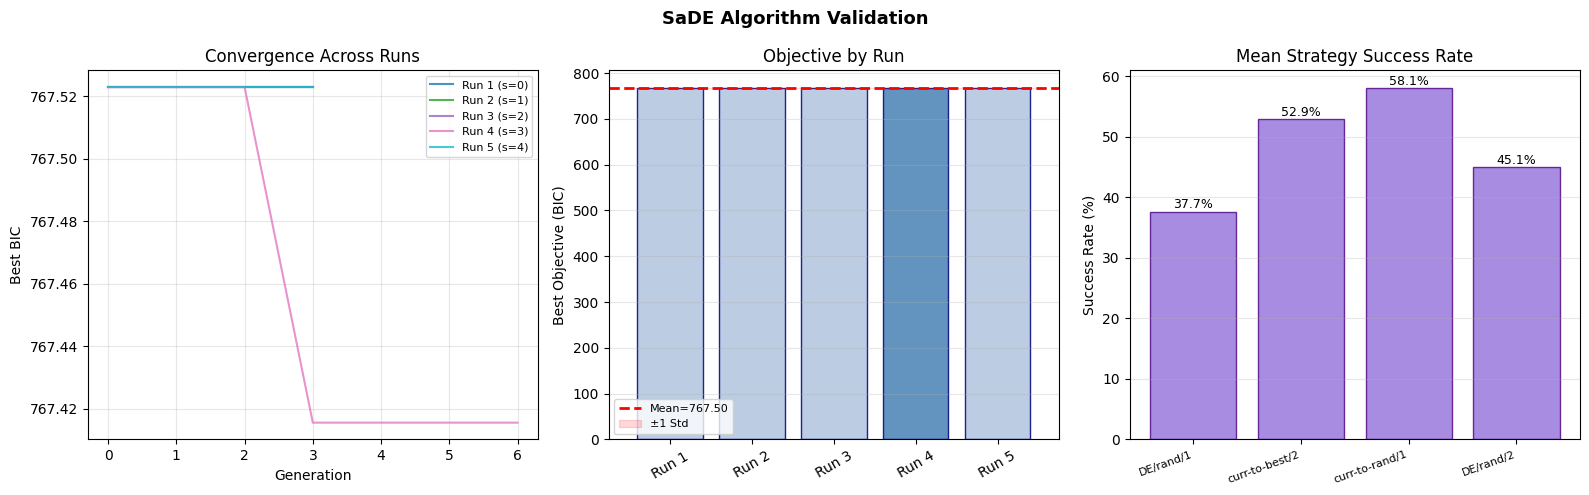

In [10]:
# == Dataset 2: Haberman =====================================================
hm_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_haberman.csv')
optimizer_hm = FPCoxOptimizer(
    df           = hm_df,
    covariates   = ['PatientAge', 'LogNodes'],
    duration_col = 'PatientYearOperation',
    event_col    = 'SurvivalStatus',
    gamma        = 0.0,
)
optimizer_hm.optimize(maxiter=15, popsize=8, seed=42)
print('\nFP Cox model summary (Haberman):')
optimizer_hm.final_fp_model.print_summary()

cv_hm = optimizer_hm.run_cross_validation(k=5, scoring_method='concordance_index', seed=0)
val_hm = optimizer_hm.validate_algorithm(n_runs=5, seeds=[0,1,2,3,4], maxiter=10, popsize=6)

Starting SaDE v6  (gamma=0.0)
  FP covariates : ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
  Simultaneous  : 5 covariates | dim=10  (FP2 max per covariate; FP1 if p2=None)
  Strata        : ['meno', 'grade', 'hormon']
  Scales applied: log_pgr÷1, log_nodes÷1, log_er÷1, age÷10, size÷10
  n=686, n_events=299  (BIC uses n_events)
  Pop size      : 80  |  Max gens : 15  |  Budget : 1200 evals
  lp (adapt)    : every 3 gens  |  patience (stop) : 5 gens
  Objective     : BIC(unpenalized) only
  Early stop at gen 8 (no improvement for 5 gens, evals used: 720)

--- Optimal Power Selection ---
  log_pgr               : p1=1       p2=None     [FP1]
  log_nodes             : p1=0       p2=-2       [FP2]
  log_er                : p1=1.5     p2=None     [FP1]
  age                   : p1=-2.5    p2=-1.5     [FP2]
  size                  : p1=-2      p2=-1       [FP2]
  Stratified on : ['meno', 'grade', 'hormon']

  Best objective : 2262.1304
  Generations    : 8
  Evaluations    : 720  (cach

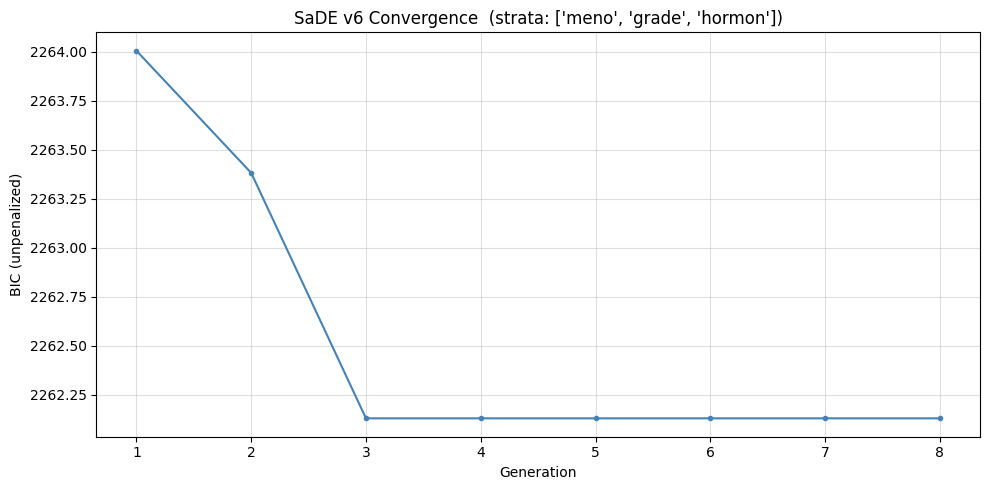


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v6)
----------------------------------------------------------------------------
Concordance index         |                 0.6673 |                 0.6822
BIC (unpen, n_events)     |                2266.30 |                2262.13
IBS (train, optimistic)   |                 0.2278 |                 0.2318
Log-lik (unpen)           |             -1118.9001 |             -1108.2634
Parameters (k)            |                      5 |                      8
  * Both models stratified on: ['meno', 'grade', 'hormon']

  Covariate scales (divide raw values by these before scoring new data):
    log_pgr: ÷1
    log_nodes: ÷1
    log_er: ÷1
    age: ÷10
    size: ÷10

MODEL EQUATIONS
Cox partial log-hazard:  log[ h(t|x) / h₀(t) ] = Σᵢ βᵢ · φᵢ(x)
Equivalent HR form    :  h(t|x) / h₀(t) = exp( Σᵢ βᵢ · φᵢ(x) )

== TRADITIONAL COX  (untransformed covariates) ==
  log[ h(t|x) / h₀(t) ] =
    − 0.18048

model,lifelines.CoxPHFitter
duration col,'rfstime'
event col,'status'
penalizer,0.01
l1 ratio,0.0
strata,"[meno, grade, hormon]"
baseline estimation,breslow
number of observations,686
number of events observed,299
partial log-likelihood,-1113.49
time fit was run,2026-03-22 15:28:41 UTC



CROSS-VALIDATION  (5-fold, metric = concordance_index)
  Note: FP powers are FIXED post-selection; Cox coefficients re-estimated per fold.

  Running traditional Cox CV...
  Running FP Cox CV...

                                        Mean         Std         Min         Max
  ----------------------------------------------------------------
  Traditional Cox                     0.6787      0.0350      0.6237      0.7219
  FP Cox (SaDE v6)                    0.6911      0.0246      0.6517      0.7247
  ----------------------------------------------------------------

  Per-fold scores:
  Fold      Traditional         FP Cox    Δ (FP−Trad)
  --------------------------------------------------
  1              0.6237         0.6517         0.0280 ↑
  2              0.7071         0.6816        -0.0255 ↓
  3              0.7219         0.7247         0.0027 ↑
  4              0.6584         0.7074         0.0490 ↑
  5              0.6825         0.6902         0.0077 ↑

  Paired t-test  (

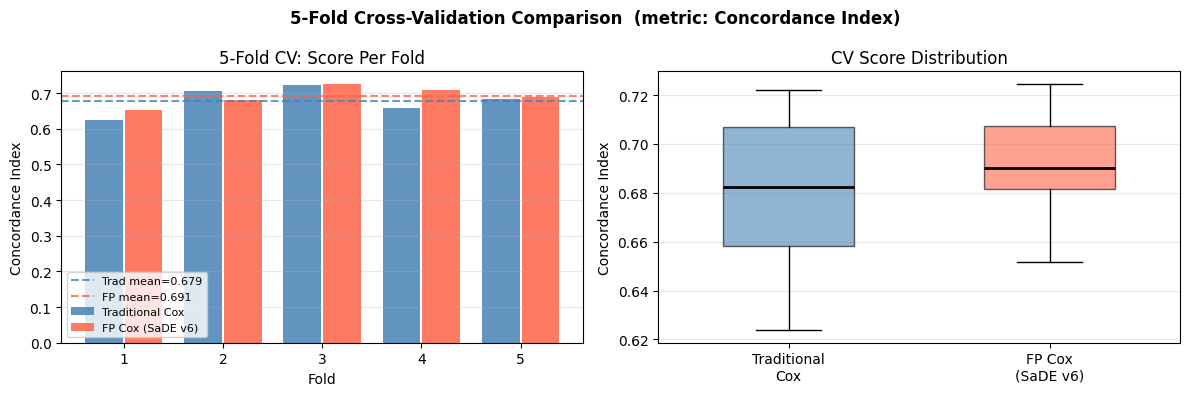


ALGORITHM VALIDATION — 5 independent SaDE runs
  maxiter=10, popsize=6, dim=10
  Seeds: [0, 1, 2, 3, 4]

  Early stop at gen 4 (no improvement for 3 gens, evals used: 300)
  Run  1 (seed=0): obj=2262.7236  gens=4  powers=[('1.5', 'None'), ('0.5', '-2'), ('0', '-1'), ('0', '-2'), ('0', 'None')]  types=['FP1', 'FP2', 'FP2', 'FP2', 'FP1']
  Early stop at gen 8 (no improvement for 3 gens, evals used: 540)
  Run  2 (seed=1): obj=2262.9940  gens=8  powers=[('0.25', '1.5'), ('-2', '-0.5'), ('0.5', 'None'), ('0.5', '-2'), ('-3', 'None')]  types=['FP2', 'FP2', 'FP1', 'FP2', 'FP1']
  Early stop at gen 5 (no improvement for 3 gens, evals used: 360)
  Run  3 (seed=2): obj=2264.4000  gens=5  powers=[('2.5', '-2.5'), ('-3', '0'), ('2', '1'), ('1', '-3'), ('None', 'None')]  types=['FP2', 'FP2', 'FP2', 'FP2', 'FP1']
  Early stop at gen 5 (no improvement for 3 gens, evals used: 360)
  Run  4 (seed=3): obj=2260.6799  gens=5  powers=[('None', '3'), ('0.25', '-1'), ('None', 'None'), ('-0.5', '-2'), ('1.5

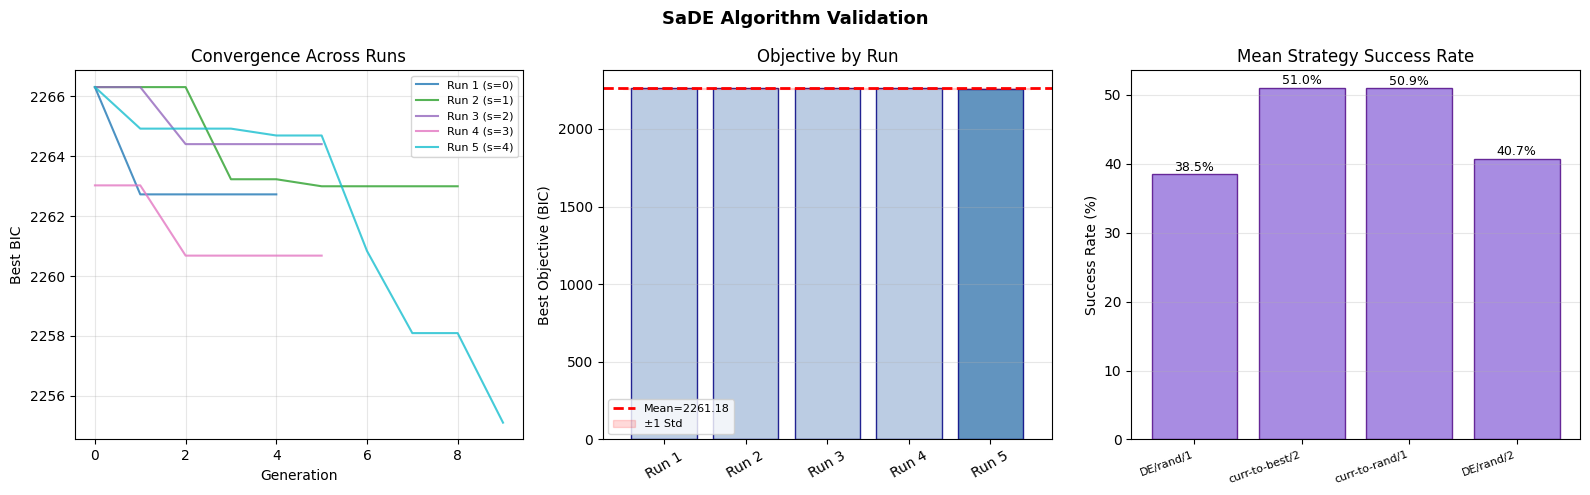

In [11]:
# == Dataset 3: GBSG =========================================================
gb_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_gbsg.csv')
GB_COVARIATES = ['log_pgr', 'log_nodes', 'log_er', 'age', 'size']
GB_STRATA     = ['meno', 'grade', 'hormon']
optimizer_gb = FPCoxOptimizer(
    df           = gb_df,
    covariates   = GB_COVARIATES,
    duration_col = 'rfstime',
    event_col    = 'status',
    strata_cols  = GB_STRATA,
    gamma        = 0.0,
)
optimizer_gb.optimize(maxiter=15, popsize=8, seed=42)
print('\nFP Cox model summary (GBSG):')
optimizer_gb.final_fp_model.print_summary()

cv_gb = optimizer_gb.run_cross_validation(k=5, scoring_method='concordance_index', seed=0)
val_gb = optimizer_gb.validate_algorithm(n_runs=5, seeds=[0,1,2,3,4], maxiter=10, popsize=6)

## Cross-Validation Quick-Reference

### Using lifelines native `k_fold_cross_validation`

```python
from lifelines import CoxPHFitter
from lifelines.utils import k_fold_cross_validation

cph = CoxPHFitter(penalizer=0.01)

# Concordance index (higher = better)
scores = k_fold_cross_validation(
    cph, df_fp_final,
    duration_col='rfstime', event_col='status',
    k=5,
    scoring_method='concordance_index',  # or 'log_likelihood'
    fitter_kwargs={'strata': ['meno', 'grade', 'hormon']},
)
print(scores)          # array of k scores
print(np.mean(scores)) # mean CV score
```

### Using scikit-learn wrapper

```python
from lifelines.utils.sklearn_adapter import sklearn_adapter
from sklearn.model_selection import cross_val_score, GridSearchCV

SKCoxPH = sklearn_adapter(CoxPHFitter, event_col='status')

# Grid-search penalizer via sklearn
param_grid = {'penalizer': [0.001, 0.01, 0.1, 1.0]}
gs = GridSearchCV(SKCoxPH(), param_grid, cv=5, scoring='neg_mean_squared_error')
gs.fit(X_fp, y)   # y = event column values
print(gs.best_params_)
```

### Summary of scoring options

| `scoring_method` | Interpretation | Better |
|---|---|---|
| `'concordance_index'` | Harrell's C-index ∈ [0, 1] | Higher |
| `'log_likelihood'` | Partial log-likelihood | Higher (less negative) |

## PH Assumption — Reference Notes

The `_test_ph_assumption()` method implements the **Grambsch-Therneau (1994)** test:

1. **Schoenfeld residuals** at event time $t_i$: $r_{ij} = x_{ij} - \bar{x}_j(t_i)$  
   where $\bar{x}_j(t_i)$ is the risk-set–weighted mean of covariate $j$ at $t_i$.

2. **Scaled residuals** are obtained by multiplying by the variance matrix of $\hat{\beta}$.

3. The test statistic is the **correlation** between scaled residuals and a function of ranked event times (default: `transform='km'` in R's `cox.zph()`).

4. **Rejection** (p < α) suggests the hazard ratio for that covariate changes over time = PH violated.

### Remedies when PH is violated

| Remedy | When to use |
|---|---|
| **Stratify** on violating covariate | Covariate is a confounder or nuisance variable |
| **Time × covariate interaction** | Want to model the time-varying effect explicitly |
| **Piecewise Cox** (time-split) | Clear early vs late effect |
| **Accelerated failure time** | Fully parametric alternative to Cox |